In [1]:
import sys
from pathlib import Path

# Find project root dynamically
def get_project_root() -> Path:
    try:
        path = Path(__file__).resolve()
        for parent in [path] + list(path.parents):
            if (parent / "requirements.txt").exists() or (parent / "project").exists():
                return parent
    except NameError:
        pass
    path = Path.cwd().resolve()
    for parent in [path] + list(path.parents):
        if (parent / "requirements.txt").exists() or (parent / "project").exists():
            return parent
    return path

ROOT = get_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
# HYPERPARAMETERS

batch_size = 128

learning_rate = 3e-4

# using SAME dimensions for image encoder and text decoder so cross-attention works directly

n_embd = 128
n_head = 4
n_layer = 4

dropout = 0.1

# maximum caption length
block_size = 32


In [4]:
# SYNTHETIC CIFAR-10 CAPTIONS

cifar_classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

captions = [
    f"this is a {cls}"
    for cls in cifar_classes
]


In [5]:
# BUILD CHARACTER VOCABULARY

all_text = "".join(captions)

chars = sorted(list(set(all_text)))

# special padding token
PAD_TOKEN = "<PAD>"

chars.append(PAD_TOKEN)

vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)} # string to integer

itos = {i: ch for i, ch in enumerate(chars)} # integer to string


# ENCODE / DECODE

def encode(text):
    return [stoi[c] for c in text]


def decode(tokens):
    return "".join(
        [itos[i] for i in tokens]
    )

PAD_IDX = stoi[PAD_TOKEN]

print("Vocabulary Size:", vocab_size)

print("Example Caption:")
print(captions[3])

print("Encoded:")
print(encode(captions[3]))

Vocabulary Size: 21
Example Caption:
this is a cat
Encoded:
[18, 8, 9, 17, 0, 9, 17, 0, 1, 0, 3, 1, 18]


In [6]:
# CIFAR-10 -> SYNTHETIC CAPTION DATASET

transform = transforms.Compose([
    transforms.ToTensor()
])


train_dataset = datasets.CIFAR10(
    root=str(ROOT / 'data'),
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root=str(ROOT / 'data'),
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 170M/170M [03:12<00:00, 886kB/s] 


In [7]:
max_caption_len = max(
    len(c)
    for c in captions
)

In [8]:
def pad_tokens(tokens):

    padding_needed = (
        max_caption_len - len(tokens)
    )

    padded = tokens + (
        [PAD_IDX] * padding_needed
    )

    return padded

In [9]:
class CaptionDataset(torch.utils.data.Dataset):

    def __init__(self, cifar_dataset):

        self.dataset = cifar_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, label = self.dataset[idx]

        # example:
        # label = 3
        # caption = "this is a cat"

        caption = f"this is a {cifar_classes[label]}"

        tokens = encode(caption)

        tokens = pad_tokens(tokens)

        tokens = torch.tensor(
            tokens,
            dtype=torch.long
        )

        input_tokens = tokens[:-1]

        target_tokens = tokens[1:]

        return (
            image,
            input_tokens,
            target_tokens
        )

In [10]:
train_dataset = CaptionDataset(train_dataset)

test_dataset = CaptionDataset(test_dataset)

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [12]:
batch = next(iter(train_loader))

images, input_tokens, target_tokens = batch

print(images.shape)
print(input_tokens.shape)
print(target_tokens.shape)

torch.Size([128, 3, 32, 32])
torch.Size([128, 19])
torch.Size([128, 19])


In [13]:
class Head(nn.Module):

    def __init__(self, head_size):

        super().__init__()

        # key, query, value projections
        # these are learned linear transformations
        # Query : what is this token looking for?
        # Key   : what information does this token contain?
        # Value : what information should this token pass forward?
        # each token gets transformed into Q,K,V vectors

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # causal mask
        # torch.tril creates lower triangular matrix
        # prevents future tokens from being visible

        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        # dropout layer - randomly removes some values during training
        # prevents overfitting
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # B = batch size
        # T = sequence length
        # C = embedding dimension

        B, T, C = x.shape

        # create key, query, value matrices
        # shape:
        # (B,T,n_embd) -> (B,T,head_size)

        k = self.key(x)       # (B,T,head_size)
        q = self.query(x)     # (B,T,head_size)
        v = self.value(x)     # (B,T,head_size)

        # attention scores
        # every token compares itself with every other token
        # transpose(-2,-1): swaps last two dimensions
        # @ = matrix multiplication
        # shape: (B,T,head_size) @ (B,head_size,T) -> (B,T,T)
        wei = q @ k.transpose(-2, -1)

        # scale scores
        # prevents values from becoming too large
        # stabilizes softmax and gradients
        wei = wei * (k.size(-1) ** -0.5)

        # apply causal mask
        # masked_fill(condition, value) -
        # wherever condition is True, replace with -inf
        # after softmax: softmax(-inf) = 0
        # so future tokens receive zero attention

        wei = wei.masked_fill(
            self.tril[:T, :T] == 0,
            float('-inf')
        )

        # convert scores to probabilities
        # softmax along last dimension
        # each row now sums to 1
        wei = F.softmax(wei, dim=-1)

        # dropout on attention probabilities
        wei = self.dropout(wei)

        # weighted aggregation of values
        # attention weights multiply value vectors
        # tokens gather information from important tokens
        # shape: (B,T,T) @ (B,T,head_size) -> (B,T,head_size)
        out = wei @ v

        return out

In [14]:
class MultiHeadAttention(nn.Module):

    def __init__(self, num_heads, head_size):

        super().__init__()

        # ModuleList:
        # special PyTorch list for storing trainable modules
        # each Head is independent

        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])

        # projection layer - learns how to combine information from all heads
        # concatenated heads are mixed together here
        # without this layer: heads would remain independent

        self.proj = nn.Linear( num_heads * head_size, n_embd)

        # dropout layer
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # concatenate outputs from all heads
        out = torch.cat([h(x) for h in self.heads], dim=-1)

        # projection layer
        # mixes information from all heads
        out = self.proj(out)

        # dropout on final output features
        out = self.dropout(out)

        return out

In [15]:
class FeedForward(nn.Module):

    def __init__(self, n_embd):

        super().__init__()

        # Sequential:
        # runs layers one after another automatically
        self.net = nn.Sequential(

            # expand dimension
            # transformer MLPs are usually 4x wider
            nn.Linear( n_embd, 4 * n_embd),

            # non-linearity
            # without activation functions, entire network becomes only linear algebra
            nn.ReLU(),

            # project back to original dimension
            nn.Linear(4 * n_embd, n_embd),

            # dropout
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


In [16]:
class CrossAttentionHead(nn.Module):

    def __init__(self, n_embd, head_size):

        super().__init__()

        # Queries, Keys and Values projections
        self.query = nn.Linear(n_embd, head_size, bias=False)

        self.key = nn.Linear(n_embd, head_size, bias=False)

        self.value = nn.Linear(n_embd,head_size,bias=False)

    def forward(self, x, context):

        # x       : (B, T_x, C)
        # context : (B, T_c, C)

        # x.shape = (2, 10, 64)
        # context.shape = (2, 5, 64)
        # head_size = 16

        # Queries come from x - (2, 10, 16)
        q = self.query(x)

        # Keys and Values come from context - (2, 5, 16)
        k = self.key(context)
        v = self.value(context)

        # Attention scores - (2, 10, 5)
        wei = q @ k.transpose(-2, -1)

        # Scale scores
        wei = wei * (k.size(-1) ** -0.5)

        # Convert to probabilities
        wei = F.softmax(wei, dim=-1)

        # Save for visualization
        self.attention_weights = wei

        self.last_attn = wei.detach().cpu()

        # No causal mask in cross-attention

        # Weighted aggregation of values - (2, 10, 16)
        out = wei @ v

        return out

In [17]:
# MULTI HEAD ATTENTION
# multiple attention heads running in parallel
class MultiHeadCrossAttention(nn.Module):

    def __init__(self, num_heads, head_size, n_embd):

        super().__init__()

        # create multiple independent attention heads
        self.heads = nn.ModuleList([
          CrossAttentionHead(n_embd, head_size)
          for _ in range(num_heads)
        ])

        # projection layer
        # mixes information from all heads together
        self.proj = nn.Linear(
            num_heads * head_size,
            n_embd
        )

    def forward(self, x, context):

        # run all heads independently
        # concatenate outputs along feature dimension
        out = torch.cat(
            [h(x, context) for h in self.heads],
            dim=-1
        )

        # projection layer
        out = self.proj(out)


        return out

In [18]:
class DecoderBlock(nn.Module):

    def __init__(self, n_embd, n_head):

        super().__init__()

        head_size = n_embd // n_head

        # SELF ATTENTION

        self.sa = MultiHeadAttention(n_head, head_size)

        # CROSS ATTENTION
        self.ca = MultiHeadCrossAttention(n_head, head_size, n_embd)

        # FEED FORWARD
        self.ffwd = FeedForward(n_embd)

        # LAYER NORMS
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ln3 = nn.LayerNorm(n_embd)

    def forward(self, x, image_features):

        # SELF ATTENTION

        x = x + self.sa(self.ln1(x))

        # CROSS ATTENTION
        # text attends to image

        x = x + self.ca(self.ln2(x), image_features)

        # FEED FORWARD

        x = x + self.ffwd(self.ln3(x))

        return x

In [19]:
class ViTHead(nn.Module):

    def __init__(self, head_size):

        super().__init__()

        self.key = nn.Linear(
            n_embd,
            head_size,
            bias=False
        )

        self.query = nn.Linear(
            n_embd,
            head_size,
            bias=False
        )

        self.value = nn.Linear(
            n_embd,
            head_size,
            bias=False
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        wei = q @ k.transpose(-2, -1)

        wei = wei * (k.size(-1) ** -0.5)

        wei = F.softmax(
            wei,
            dim=-1
        )

        wei = self.dropout(wei)

        out = wei @ v

        return out

In [20]:
class ViTMultiHeadAttention(nn.Module):

    def __init__(
        self,
        num_heads,
        head_size
    ):

        super().__init__()

        self.heads = nn.ModuleList([
            ViTHead(head_size)
            for _ in range(num_heads)
        ])

        self.proj = nn.Linear(
            num_heads * head_size,
            n_embd
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        out = torch.cat(
            [h(x) for h in self.heads],
            dim=-1
        )

        out = self.proj(out)

        out = self.dropout(out)

        return out

In [21]:
class ViTBlock(nn.Module):

    def __init__(
        self,
        n_embd,
        n_head
    ):

        super().__init__()

        head_size = n_embd // n_head

        self.sa = ViTMultiHeadAttention(
            n_head,
            head_size
        )

        self.ffwd = FeedForward(n_embd)

        self.ln1 = nn.LayerNorm(n_embd)

        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):

        x = x + self.sa(
            self.ln1(x)
        )

        x = x + self.ffwd(
            self.ln2(x)
        )

        return x

In [22]:
class ViTEncoder(nn.Module):

    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_chans=3,
        n_embd=192,
        n_head=6,
        n_layer=6,
        dropout=0.1
    ):

        super().__init__()

        # NUMBER OF PATCHES
        num_patches = (img_size // patch_size) ** 2

        # PATCH EMBEDDING

        self.patch_embed = nn.Conv2d(
            in_channels=in_chans,
            out_channels=n_embd,
            kernel_size=patch_size,
            stride=patch_size
        )

        # CLS TOKEN

        self.cls_token = nn.Parameter(torch.zeros(1, 1, n_embd))

        # POSITION EMBEDDINGS

        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, n_embd))

        self.dropout = nn.Dropout(dropout)

        # TRANSFORMER BLOCKS

        self.blocks = nn.Sequential(
            *[
                ViTBlock(n_embd, n_head)
                for _ in range(n_layer)
            ]
        )

        self.norm = nn.LayerNorm(n_embd)

        nn.init.trunc_normal_(self.cls_token, std=0.02)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):

        B = x.shape[0]

        # PATCH EMBEDDING

        x = self.patch_embed(x)

        # (B,192,8,8)

        x = x.flatten(2)

        # (B,192,64)

        x = x.transpose(1, 2)

        # (B,64,192)

        # CLS TOKEN

        cls = self.cls_token.expand(B, -1, -1)

        x = torch.cat([cls, x], dim=1)

        # (B,65,192)

        # POSITION EMBEDDINGS

        x = x + self.pos_embed

        x = self.dropout(x)

        # TRANSFORMER

        x = self.blocks(x)

        x = self.norm(x)

        # IMPORTANT:
        # return ALL image tokens

        return x

In [23]:
class MultimodalModel(nn.Module):

    def __init__(self):

        super().__init__()

        # IMAGE ENCODER

        self.vision_encoder = ViTEncoder(
            img_size=32,
            patch_size=4,
            n_embd=n_embd,
            n_head=n_head,
            n_layer=n_layer
        )

        # TOKEN EMBEDDINGS

        self.token_embedding_table = nn.Embedding(
            vocab_size,
            n_embd
        )

        # POSITION EMBEDDINGS

        self.position_embedding_table = nn.Embedding(
            block_size,
            n_embd
        )

        # DECODER BLOCKS

        self.blocks = nn.ModuleList([
            DecoderBlock(
                n_embd,
                n_head
            )
            for _ in range(n_layer)
        ])

        # FINAL NORM

        self.ln_f = nn.LayerNorm(n_embd)

        # LM HEAD

        self.lm_head = nn.Linear(
            n_embd,
            vocab_size
        )

    def forward(
        self,
        images,
        input_tokens,
        targets=None
    ):

        # IMAGE FEATURES

        image_features = self.vision_encoder(
            images
        )

        # (B,65,192)

        # TEXT EMBEDDINGS

        B, T = input_tokens.shape

        tok_emb = self.token_embedding_table(
            input_tokens
        )

        pos_emb = self.position_embedding_table(
            torch.arange(
                T,
                device=input_tokens.device
            )
        )

        x = tok_emb + pos_emb

        # DECODER

        for block in self.blocks:

            x = block(
                x,
                image_features
            )

        x = self.ln_f(x)

        logits = self.lm_head(x)

        # LOSS

        loss = None

        if targets is not None:

            B, T, C = logits.shape

            loss = F.cross_entropy(
                logits.view(B * T, C),
                targets.view(B * T),
                ignore_index=PAD_IDX
            )

        return logits, loss

    def generate_caption(
        self,
        image,
        max_new_tokens=25
    ):

        self.eval()

        with torch.no_grad():



            image = image.unsqueeze(0).to(device)

            image_features = self.vision_encoder(
                image
            )


            start_text = "t"

            tokens = torch.tensor(
                [encode(start_text)],
                dtype=torch.long,
                device=device
            )



            for _ in range(max_new_tokens):

                B, T = tokens.shape

                tok_emb = self.token_embedding_table(
                    tokens
                )

                pos_emb = self.position_embedding_table(
                    torch.arange(
                        T,
                        device=device
                    )
                )

                x = tok_emb + pos_emb

                for block in self.blocks:

                    x = block(
                        x,
                        image_features
                    )

                x = self.ln_f(x)

                logits = self.lm_head(x)

                logits = logits[:, -1, :]

                probs = F.softmax(
                    logits,
                    dim=-1
                )

                next_token = torch.multinomial(
                    probs,
                    num_samples=1
                )

                tokens = torch.cat(
                    [tokens, next_token],
                    dim=1
                )

            caption = decode(
                tokens[0].tolist()
            )

            return caption

In [24]:
model = MultimodalModel().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate
)

In [25]:
loss_history = []

In [26]:


epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for images, input_tokens, target_tokens in train_loader:

        images = images.to(device)

        input_tokens = input_tokens.to(device)

        target_tokens = target_tokens.to(device)

        # forward pass
        logits, loss = model(
            images,
            input_tokens,
            target_tokens
        )

        attn = model.blocks[0].ca.heads[0].last_attn

        # clear old gradients
        optimizer.zero_grad()

        # backpropagation
        loss.backward()

        # update weights
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {avg_loss:.4f}"
    )

Epoch 1/10 | Loss: 0.2462
Epoch 2/10 | Loss: 0.1194
Epoch 3/10 | Loss: 0.1041
Epoch 4/10 | Loss: 0.0958
Epoch 5/10 | Loss: 0.0900
Epoch 6/10 | Loss: 0.0858
Epoch 7/10 | Loss: 0.0829
Epoch 8/10 | Loss: 0.0792
Epoch 9/10 | Loss: 0.0763
Epoch 10/10 | Loss: 0.0738


In [27]:
attn = attn[:, :,  1:]

In [28]:

print(attn.shape)

torch.Size([80, 19, 64])


In [29]:
attn = attn[0]
print(attn.shape)

torch.Size([19, 64])


In [30]:
import matplotlib.pyplot as plt


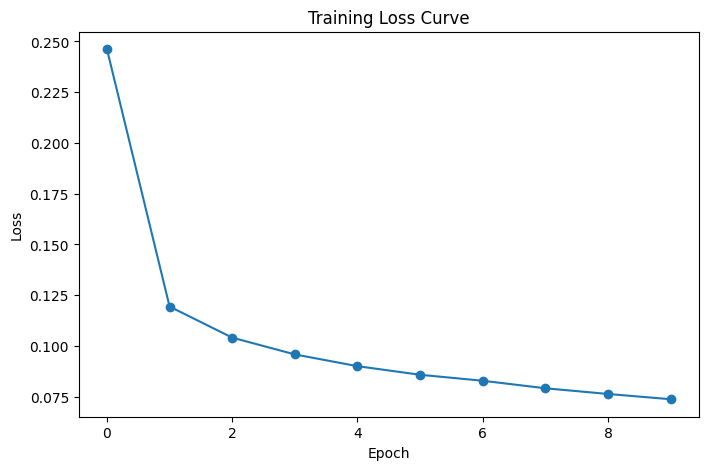

In [31]:
plt.figure(figsize=(8,5))
plt.plot(loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.savefig("training_curve.png")
plt.show()

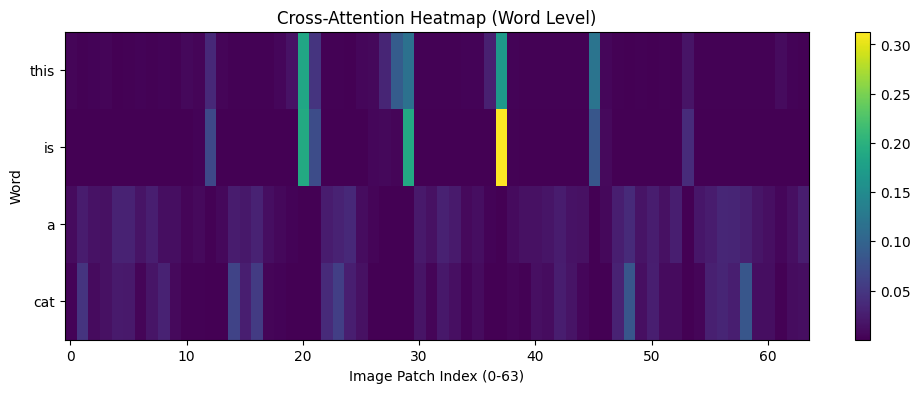

In [32]:
import matplotlib.pyplot as plt

# run one forward pass on a single image
images, input_tokens, target_tokens = next(iter(train_loader))
image = images[:1].to(device)
input_tokens = input_tokens[:1].to(device)

with torch.no_grad():
    logits, _ = model(image, input_tokens)

# get attention from last decoder block, first cross-attention head
attn = model.blocks[-1].ca.heads[0].last_attn  # (1, T_text, 65)
attn = attn[0].cpu()    # (T_text, 65)
attn = attn[:, 1:]      # (T_text, 64) — drop CLS column

# figure out which image this was and what its caption should be
# input_tokens[0] contains the encoded caption - decode it to find the class
decoded = decode(input_tokens[0].cpu().tolist())
# decoded looks like "this is a cat<PAD><PAD>..."
# strip padding and spaces to get the clean caption
caption_str = decoded.replace("<PAD>", "").strip()
words = caption_str.split()   # ["this", "is", "a", "cat"]

word_attn = []
char_idx = 0

for i, word in enumerate(words):
    start = char_idx
    end = char_idx + len(word)

    if i == 0:
        # The first word ("this") is the start of the sequence,
        # so we can just average its characters.
        word_row = attn[start:end, :].mean(dim=0)
    else:
        # This is the step where the model queried the image to predict the first letter.
        word_row = attn[start - 1, :]

    word_attn.append(word_row)

    # advance to the next word, skipping the space
    char_idx = end + 1

word_attn = torch.stack(word_attn)   # (num_words, 64)

# plot word-level heatmap
plt.figure(figsize=(12, 4))
plt.imshow(word_attn, aspect='auto')
plt.xlabel("Image Patch Index (0-63)")
plt.ylabel("Word")
plt.title("Cross-Attention Heatmap (Word Level)")
plt.yticks(ticks=range(len(words)), labels=words)
plt.colorbar()
plt.savefig("attention_viz.png")
plt.show()

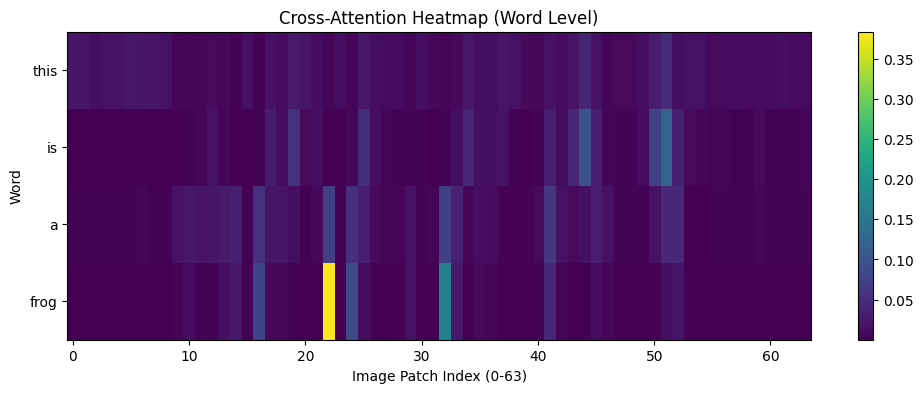

In [35]:
import matplotlib.pyplot as plt

# run one forward pass on a single image
images, input_tokens, target_tokens = next(iter(train_loader))
image = images[:1].to(device)
input_tokens = input_tokens[:1].to(device)

with torch.no_grad():
    logits, _ = model(image, input_tokens)

# get attention from last decoder block, first cross-attention head
attn = model.blocks[-1].ca.heads[0].last_attn  # (1, T_text, 65)
attn = attn[0].cpu()    # (T_text, 65)
attn = attn[:, 1:]      # (T_text, 64) — drop CLS column

# figure out which image this was and what its caption should be
# input_tokens[0] contains the encoded caption - decode it to find the class
decoded = decode(input_tokens[0].cpu().tolist())
# decoded looks like "this is a cat<PAD><PAD>..."
# strip padding and spaces to get the clean caption
caption_str = decoded.replace("<PAD>", "").strip()
words = caption_str.split()   # ["this", "is", "a", "cat"]

word_attn = []
char_idx = 0

for i, word in enumerate(words):
    start = char_idx
    end = char_idx + len(word)

    if i == 0:
        # The first word ("this") is the start of the sequence,
        # so we can just average its characters.
        word_row = attn[start:end, :].mean(dim=0)
    else:
        # This is the step where the model queried the image to predict the first letter.
        word_row = attn[start - 1, :]

    word_attn.append(word_row)

    # advance to the next word, skipping the space
    char_idx = end + 1

word_attn = torch.stack(word_attn)   # (num_words, 64)

# plot word-level heatmap
plt.figure(figsize=(12, 4))
plt.imshow(word_attn, aspect='auto')
plt.xlabel("Image Patch Index (0-63)")
plt.ylabel("Word")
plt.title("Cross-Attention Heatmap (Word Level)")
plt.yticks(ticks=range(len(words)), labels=words)
plt.colorbar()
plt.savefig("attention_viz.png")
plt.show()

In [33]:

test_images, _, _ = next(iter(test_loader))

with open(ROOT / "TASK 4" / "samples.txt", "w") as f:
    for i in range(5):
        image = test_images[i]
        caption = model.generate_caption(image)
        line = f"Image {i+1}: {caption}\n"
        f.write(line)
        print(line)


Image 1: this is a catomobileseeeee

Image 2: this is a airplanelerplauc

Image 3: this is a shiplaneleeelaip

Image 4: this is a airplaneleeeskne

Image 5: this is a frogeromoerogfro

